In [1]:
import os
import numpy as np
import pandas as pd
import scipy
import anndata
import scanpy as sc
import pybiomart
import scvi
import torch
import random
import seaborn as sns

In [2]:
cwd = os.getcwd()
cwd

'/home/merlin/Documents/Programming/FigureOneLab/trevino'

In [3]:
# Load metadata into pandas dataframe
meta = pd.read_csv(cwd+'/data/GSE162170_rna_cell_metadata.txt.gz', compression='gzip', sep='\t')
meta.index = meta['Cell.ID']  # Cell ID's as row names
meta.index.name = None  # Clean up index names

In [4]:
%%time
# Old approach was causing OOM issues due to large file size and duplication in transpose function
# counts = pd.read_csv(cwd+'/data/GSE162170_rna_counts.tsv.gz', compression='gzip', sep='\t')
# counts = counts.transpose()
# counts

# Using built in scanpy function directly
adata = sc.read_csv(cwd+'/data/GSE162170_rna_counts.tsv.gz', delimiter='\t')

CPU times: user 1min 18s, sys: 2.52 s, total: 1min 21s
Wall time: 1min 21s


In [5]:
adata = adata.transpose()

In [6]:
np.random.seed(42)
n_dev_cells = 1000
dev_cell_indices = np.random.choice(adata.n_obs, size=n_dev_cells, replace = False)

# Subset the data for development
adata_dev = adata[dev_cell_indices, :].copy()

In [7]:
%%time
# adata = anndata.AnnData(X=counts,
#                         obs=meta,
#                         var=counts.columns.to_frame())

adata_dev.obs = meta.loc[adata_dev.obs.index]  # Align by cell ID
adata_dev

CPU times: user 9.09 ms, sys: 869 µs, total: 9.96 ms
Wall time: 11.6 ms


AnnData object with n_obs × n_vars = 1000 × 33355
    obs: 'Cell.ID', 'Sample.ID', 'Age', 'Tissue.ID', 'Sample.Type', 'Assay', 'Batch', 'seurat_clusters', 'RNA.Counts', 'RNA.Features', 'Percent.MT', 'Percent.Ribo', 'Cell.Barcode', 'DF_pANN', 'DF_classification', 'DF_pANN_quantile', 'Spliced.Counts', 'Spliced.Features', 'Unspliced.Counts', 'Unspliced.Features', 'Ambiguous.Counts', 'Ambiguous.Features'

In [8]:
print(f"Development subset: {adata_dev.n_obs} cells, {adata_dev.n_vars}")
print(adata_dev.var.head())

Development subset: 1000 cells, 33355
Empty DataFrame
Columns: []
Index: [ENSG00000243485, ENSG00000237613, ENSG00000186092, ENSG00000238009, ENSG00000239945]


In [9]:
%%time
a = sc.queries.biomart_annotations('hsapiens', ['ensembl_gene_id','hgnc_symbol'])
b = dict(zip(a['ensembl_gene_id'], a['hgnc_symbol']))
adata_dev.var['hgnc_symbol'] = adata_dev.var.index.map(b)
adata_dev.var.index = adata_dev.var['hgnc_symbol']
adata_dev.var.index.name = None
adata_dev.var.drop(columns=['hgnc_symbol'], inplace=True)
adata_dev.var

CPU times: user 402 ms, sys: 12.9 ms, total: 415 ms
Wall time: 8.74 s


""
MIR1302-2HG
FAM138A
OR4F5
NaN
NaN
...
MT-ND4L
MT-ND4
MT-ND5
MT-ND6


In [10]:
adata_dev.var_names_make_unique

<bound method AnnData.var_names_make_unique of AnnData object with n_obs × n_vars = 1000 × 33355
    obs: 'Cell.ID', 'Sample.ID', 'Age', 'Tissue.ID', 'Sample.Type', 'Assay', 'Batch', 'seurat_clusters', 'RNA.Counts', 'RNA.Features', 'Percent.MT', 'Percent.Ribo', 'Cell.Barcode', 'DF_pANN', 'DF_classification', 'DF_pANN_quantile', 'Spliced.Counts', 'Spliced.Features', 'Unspliced.Counts', 'Unspliced.Features', 'Ambiguous.Counts', 'Ambiguous.Features'>

In [11]:
a = ~adata_dev.var.index.isnull()
# Also OOM error while running due to duplicate creation
# adata = adata[:,a].copy()
# Instead subset using direct approach to reduce memory usage

adata_dev = adata_dev[:, a]

In [12]:
adata_dev

View of AnnData object with n_obs × n_vars = 1000 × 25109
    obs: 'Cell.ID', 'Sample.ID', 'Age', 'Tissue.ID', 'Sample.Type', 'Assay', 'Batch', 'seurat_clusters', 'RNA.Counts', 'RNA.Features', 'Percent.MT', 'Percent.Ribo', 'Cell.Barcode', 'DF_pANN', 'DF_classification', 'DF_pANN_quantile', 'Spliced.Counts', 'Spliced.Features', 'Unspliced.Counts', 'Unspliced.Features', 'Ambiguous.Counts', 'Ambiguous.Features'

In [13]:
%%time
sc.pp.filter_genes(adata_dev, min_cells=10)
sc.pp.filter_cells(adata_dev, min_genes=200)

CPU times: user 295 ms, sys: 52 µs, total: 295 ms
Wall time: 299 ms


/home/merlin/miniconda3/envs/figure-one-lab/lib/python3.9/site-packages/scanpy/preprocessing/_simple.py:283: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["n_cells"] = number
/home/merlin/miniconda3/envs/figure-one-lab/lib/python3.9/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/merlin/miniconda3/envs/figure-one-lab/lib/python3.9/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [ ]:
#sc.pp.subsample(adata, n_obs=40000, random_state=0, copy=False)

In [14]:
%%time
adata_dev.X = scipy.sparse.csr_matrix(adata_dev.X.copy())
adata_dev.layers['counts'] = scipy.sparse.csr_matrix(adata_dev.X.copy())
#adata.layers['log2_counts'] = sc.pp.log1p(adata.layers['counts'].copy(), base=2)

CPU times: user 116 ms, sys: 0 ns, total: 116 ms
Wall time: 115 ms


In [15]:
%%time
random.seed(17)
scvi.model.SCVI.setup_anndata(adata_dev, layer='counts', batch_key='Sample.ID')
scvi_model = scvi.model.SCVI(adata_dev, n_layers=2, n_latent=30, n_hidden=128, gene_likelihood='nb')
scvi_model.train()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/merlin/miniconda3/envs/figure-one-lab/lib/python3.9/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
/home/merlin/miniconda3/envs/figure-one-lab/lib/python3.9/site-packages/lightning/pytorch/loops/fit_loop.py:310: The number of training batches (8) is smaller than the logging interval Trainer(log_every_n_steps=10). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Epoch 400/400: 100%|██████████| 400/400 [03:09<00:00,  2.16it/s, v_num=1, train_loss_step=9.08e+3, train_loss_epoch=5.86e+3]

`Trainer.fit` stopped: `max_epochs=400` reached.


Epoch 400/400: 100%|██████████| 400/400 [03:09<00:00,  2.11it/s, v_num=1, train_loss_step=9.08e+3, train_loss_epoch=5.86e+3]
CPU times: user 24min 50s, sys: 14.9 s, total: 25min 5s
Wall time: 3min 10s


In [16]:
%%time
random.seed(17)
adata_dev.obsm['X_scvi'] = scvi_model.get_latent_representation()
adata_dev.layers['counts_scvi'] = scvi_model.get_normalized_expression(library_size=10000)
#adata.layers['log2_counts_scvi'] = sc.pp.log1p(adata.layers['counts_scvi'].copy(), base=2)

CPU times: user 1.04 s, sys: 12.9 ms, total: 1.05 s
Wall time: 137 ms


<timed exec>:2: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.


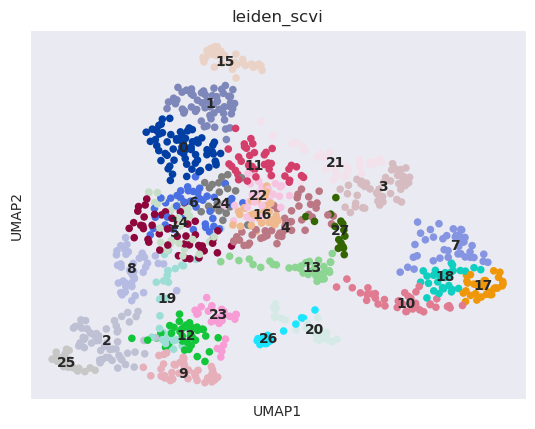

CPU times: user 3.7 s, sys: 139 ms, total: 3.84 s
Wall time: 2.36 s


In [19]:
%%time
sc.pp.neighbors(adata_dev, use_rep='X_scvi', key_added='neighbors_scvi', n_neighbors=20)
sc.tl.leiden(adata_dev, neighbors_key='neighbors_scvi', key_added='leiden_scvi', resolution=3)
sc.tl.umap(adata_dev, neighbors_key='neighbors_scvi')
sc.pl.umap(adata_dev, color=['leiden_scvi'], legend_loc='on data')

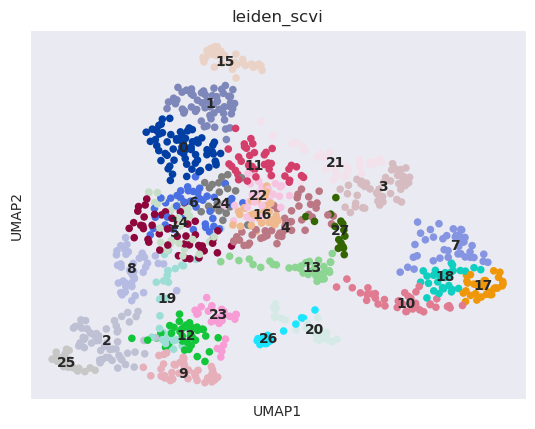

CPU times: user 2.26 s, sys: 74.7 ms, total: 2.34 s
Wall time: 879 ms


In [20]:
%%time
sc.pp.neighbors(adata_dev, use_rep='X_scvi', key_added='neighbors_scvi', n_neighbors=20)
sc.tl.leiden(adata_dev, neighbors_key='neighbors_scvi', key_added='leiden_scvi', resolution=3)
sc.tl.umap(adata_dev, neighbors_key='neighbors_scvi')
sc.pl.umap(adata_dev, color=['leiden_scvi'], legend_loc='on data')

In [23]:
%%time
adata_dev.write(cwd+'/outs/231226_trevino_rna_scvi.h5ad')

CPU times: user 38.7 ms, sys: 27.7 ms, total: 66.3 ms
Wall time: 81.6 ms
